# Auto MPG Prediction — End-to-End Data Analytics Project
**Author:** Pratik Pawar

**Goal:** Explore the classic Auto MPG dataset, clean it, understand what drives a car's fuel efficiency (mpg), and build a Linear Regression model to predict mpg from a car's specifications (weight, horsepower, displacement, cylinders, etc.).

**Workflow:** Data Loading → Cleaning → EDA → Feature Prep → Linear Regression → Evaluation → Business Insight


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)


## 1. Load the Data
Using the classic Auto MPG dataset (398 cars, late 1970s-80s US/Japan/Europe models).

In [2]:
df = sns.load_dataset('mpg')
print("Shape:", df.shape)
df.head()


Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


## 2. Data Cleaning
Check for missing values and duplicates, then handle them.

In [4]:
df.isnull().sum()


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [5]:
# horsepower has a few missing values (some cars had "?" in the original dataset)
# Since it's a small number of rows relative to the dataset, we impute with the median
# rather than dropping rows and losing data.
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

print("Duplicate rows:", df.duplicated().sum())
df.isnull().sum()


Duplicate rows: 0


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [6]:
df.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## 3. Exploratory Data Analysis (EDA)
Understand relationships between mpg and other features before modeling.

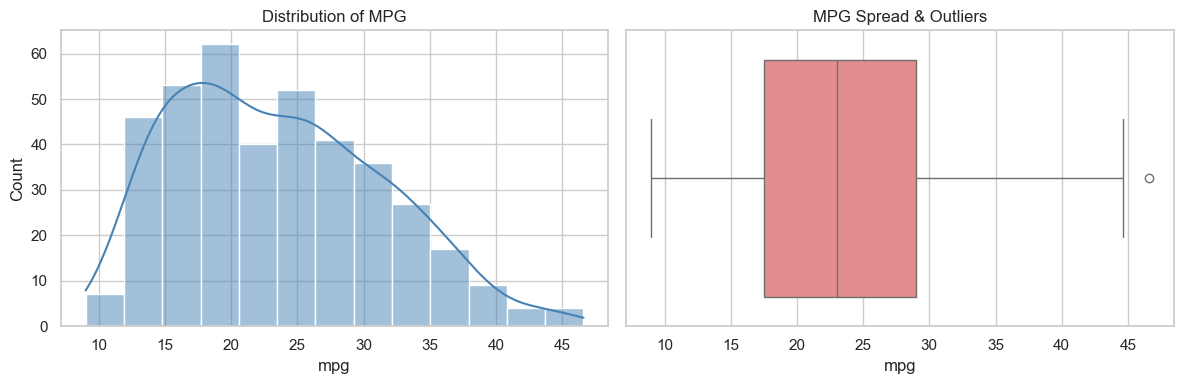

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['mpg'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of MPG')
sns.boxplot(x=df['mpg'], ax=axes[1], color='lightcoral')
axes[1].set_title('MPG Spread & Outliers')
plt.tight_layout()
plt.show()


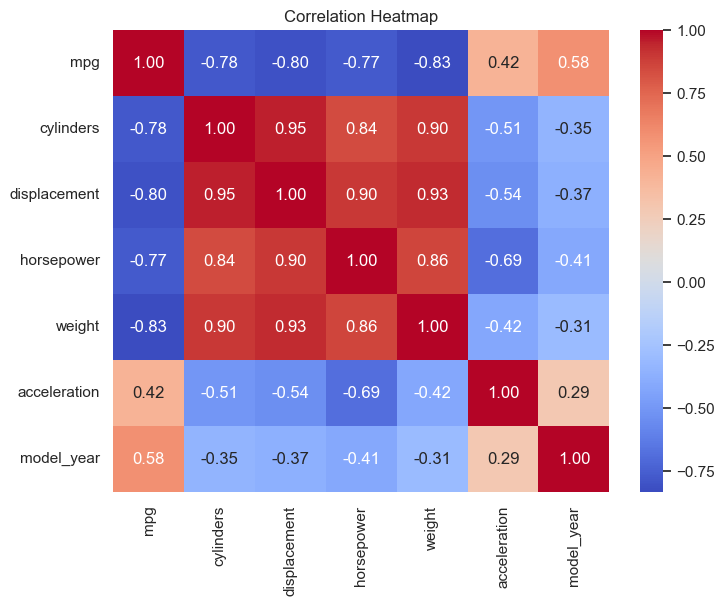

In [8]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


**Insight:** `weight`, `displacement`, `horsepower`, and `cylinders` are all strongly **negatively** correlated with `mpg` — heavier, bigger-engine cars are less fuel-efficient. `weight` has the strongest correlation, so it's likely the single best predictor.

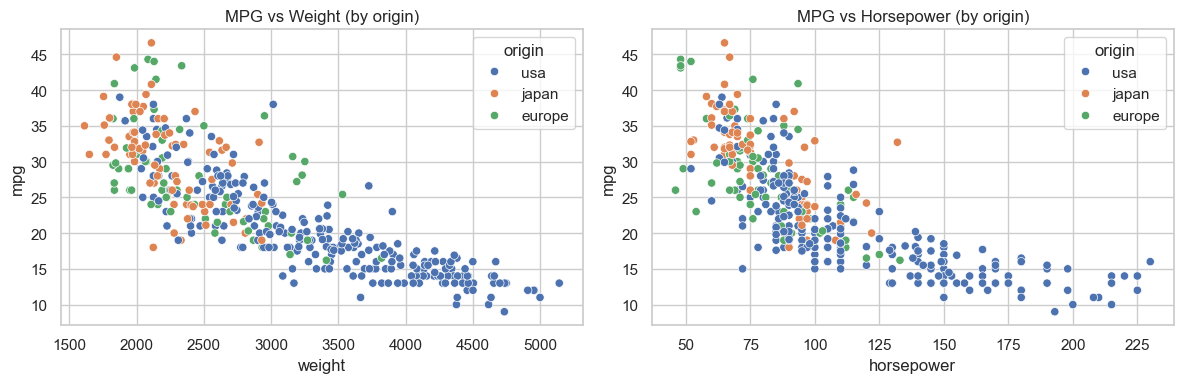

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df, x='weight', y='mpg', hue='origin', ax=axes[0])
axes[0].set_title('MPG vs Weight (by origin)')
sns.scatterplot(data=df, x='horsepower', y='mpg', hue='origin', ax=axes[1])
axes[1].set_title('MPG vs Horsepower (by origin)')
plt.tight_layout()
plt.show()


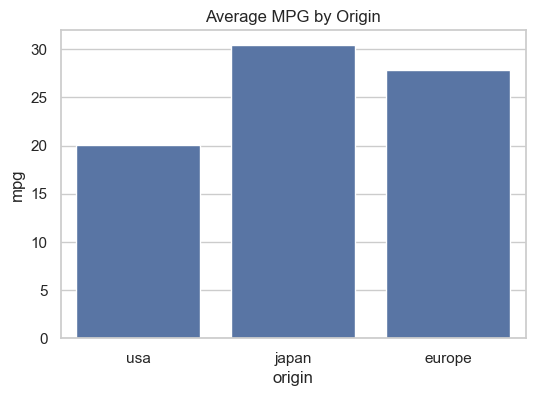

In [10]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='origin', y='mpg', estimator=np.mean, errorbar=None)
plt.title('Average MPG by Origin')
plt.show()


**Insight:** Japanese and European cars average noticeably higher mpg than US cars in this era — consistent with US cars historically favoring larger engines.

## 4. Feature Preparation

In [11]:
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
X = df[features]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (318, 6) Test shape: (80, 6)


## 5. Build the Linear Regression Model

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

coef_df = pd.DataFrame({'feature': features, 'coefficient': model.coef_})
coef_df.sort_values('coefficient', key=abs, ascending=False)


,feature,coefficient
5,model_year,0.801365
4,acceleration,0.080614
0,cylinders,0.069049
3,weight,-0.007044
2,horsepower,0.002898
1,displacement,0.001604


## 6. Evaluate the Model

In [13]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} mpg")
print(f"RMSE: {rmse:.2f} mpg")
print(f"R²:   {r2:.3f}")


MAE:  2.47 mpg
RMSE: 3.07 mpg
R²:   0.824


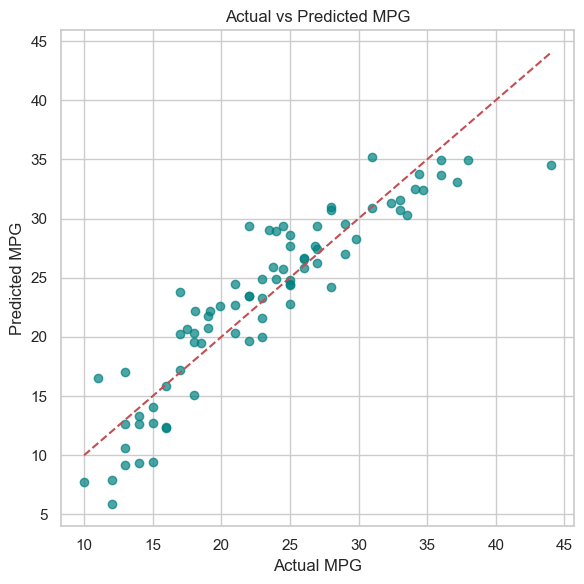

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG')
plt.tight_layout()
plt.show()


In [15]:
print(f"Model explains about {r2*100:.0f}% of the variance in mpg (R² = {r2:.3f}),")
print(f"with an average prediction error of about {mae:.1f} mpg (MAE).")


Model explains about 82% of the variance in mpg (R² = 0.824),
with an average prediction error of about 2.5 mpg (MAE).


## 7. Business Insight / Conclusion

- The R² and MAE above show how well weight, horsepower, displacement, cylinders, acceleration, and model year together predict mpg.
- **Weight** is the single strongest driver of fuel efficiency — every extra unit of weight has the largest negative pull on mpg.
- **Model year** has a positive coefficient — newer cars in the dataset are more fuel-efficient, reflecting engine efficiency improvements over time.
- **Practical takeaway:** if a manufacturer wants to improve fleet mpg, reducing vehicle weight has more impact than any other single lever in this dataset.
